# Datathon Passos Mágicos - Análise Exploratória e Modelagem

Este notebook apresenta a análise exploratória dos dados (EDA), o pré-processamento e o treinamento do modelo de Machine Learning para previsão de risco de defasagem escolar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Adicionar diretório pai ao path para importar modulos src
sys.path.append('..')

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregamento dos Dados
Carregando os dados brutos e visualizando as primeiras linhas.

In [ ]:
from src.data_cleaning import load_data

DATA_PATH = "../app/data/raw/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"
df_raw = load_data(DATA_PATH)
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (1156, 50)


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


## 2. Análise Exploratória (EDA)

/tmp/ipykernel_59859/1621747936.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values[:30], y=missing.index[:30], palette='viridis')


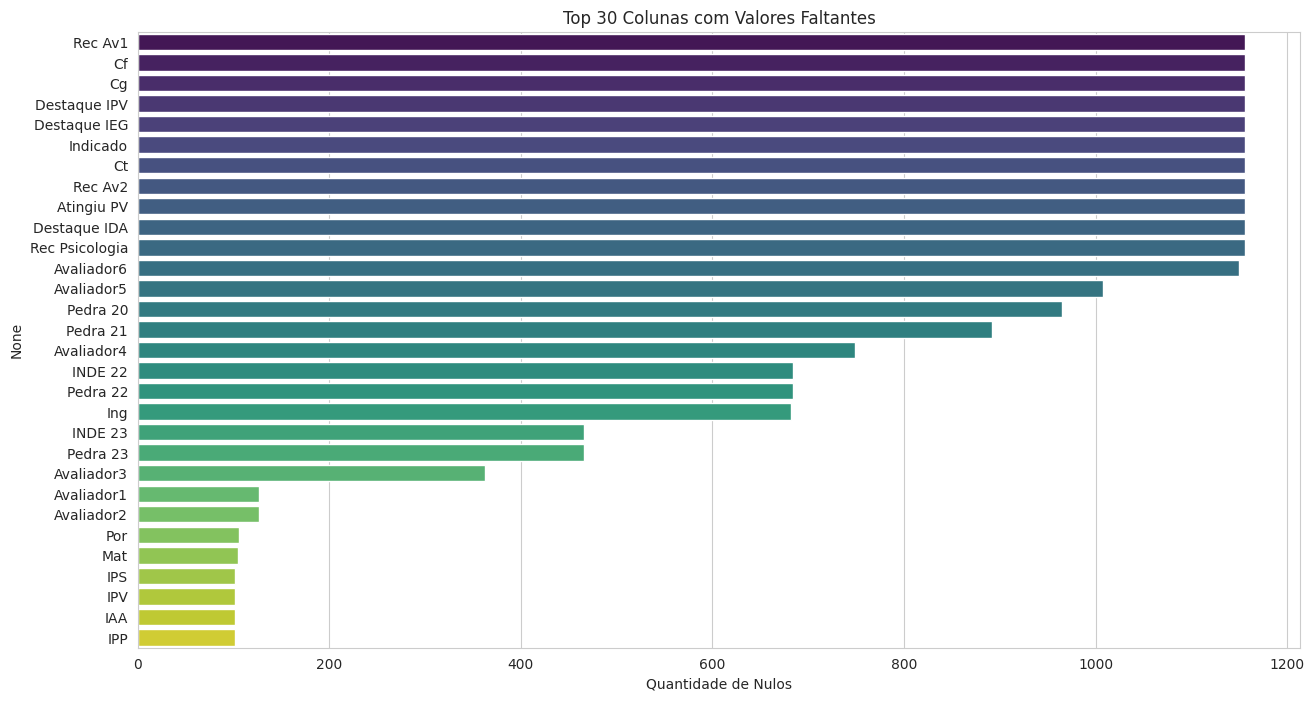

In [3]:
# Analisando valores nulos
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=missing.values[:30], y=missing.index[:30], palette='viridis')
plt.title('Top 30 Colunas com Valores Faltantes')
plt.xlabel('Quantidade de Nulos')
plt.show()

### Variável Alvo: Defasagem
A coluna `Defasagem` indica o nível de atraso escolar. Valores negativos indicam atraso.

/tmp/ipykernel_59859/3518986630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='Defasagem', palette='coolwarm')


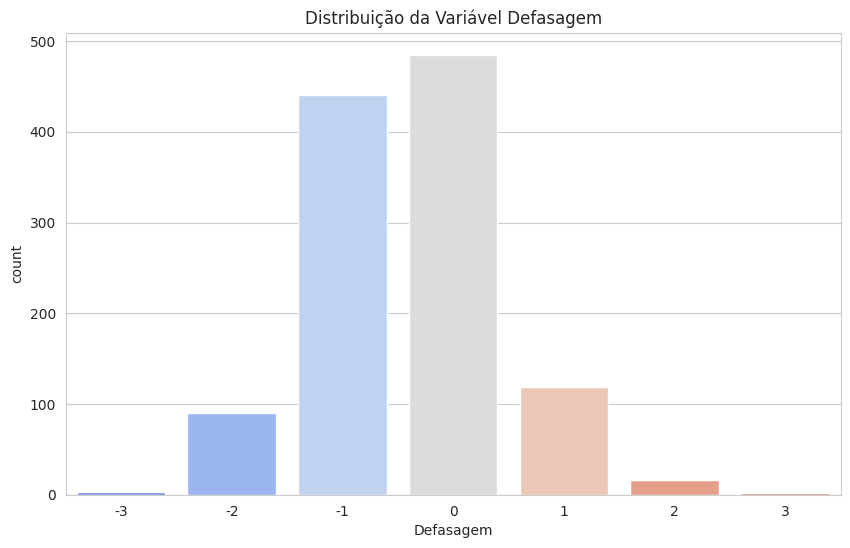

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_raw, x='Defasagem', palette='coolwarm')
plt.title('Distribuição da Variável Defasagem')
plt.show()

## 3. Pré-processamento
Aplicação das transformações definidas no pipeline de engenharia:
1. Limpeza básica.
2. Criação do Target Binário (1 = Risco, 0 = Sem Risco).
3. Trat Nulos.
4. Feature Engineering.

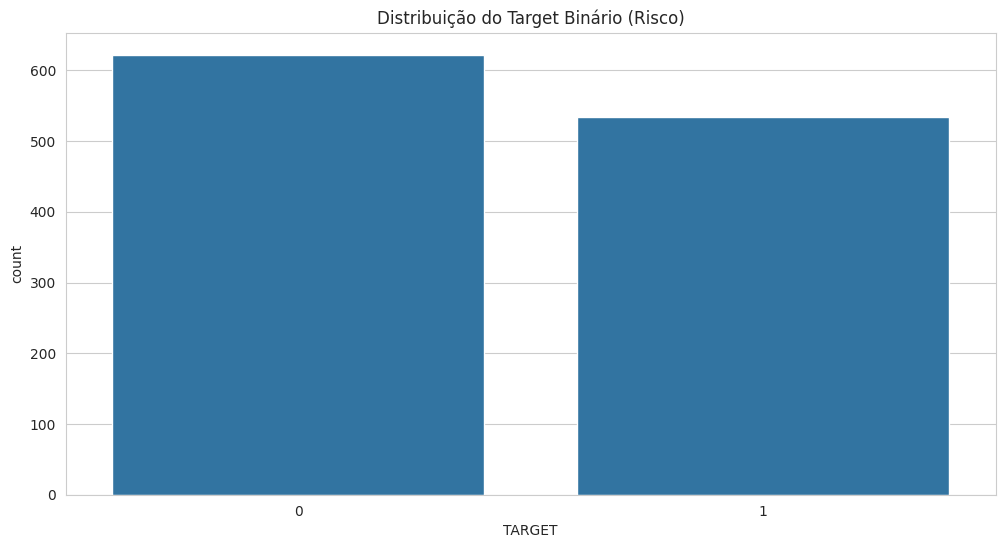

In [5]:
from src.data_cleaning import clean_data, create_target, handle_missing_values
from src.feature_engineering import create_features, select_features

# Pipeline de transformação
df = clean_data(df_raw)
df = create_target(df)
df = handle_missing_values(df)
df = create_features(df)

# Visualizando o Target criado
sns.countplot(x=df['TARGET'])
plt.title('Distribuição do Target Binário (Risco)')
plt.show()

## 4. Seleção de Features e Divisão
Removendo colunas que causam Data Leakage (indicadores de 2024).

In [6]:
X, y = select_features(df)
print(f"Features selecionadas ({X.shape[1]}):", X.columns.tolist())

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Features selecionadas (28): ['FASE', 'TURMA', 'DATA_DE_NASC', 'IDADE', 'GÊNERO', 'ANO_INGRESSO', 'INSTITUIÇÃO_DE_ENSINO', 'PEDRA_20', 'PEDRA_21', 'PEDRA_22', 'PEDRA_23', 'INDE_22', 'INDE_23', 'CG', 'CF', 'CT', 'Nº_AV', 'AVALIADOR1', 'AVALIADOR2', 'AVALIADOR3', 'AVALIADOR4', 'AVALIADOR5', 'AVALIADOR6', 'FASE_IDEAL', 'ESCOLA', 'ATIVO/_INATIVO', 'ATIVO/_INATIVO.1', 'HAS_HISTORY_23']


## 5. Treinamento e Avaliação do Modelo
Treinando o RandomForest e visualizando métricas detalhadas.

In [7]:
from src.model import train_model
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay

# Treinamento
model, metrics = train_model(X, y)

print("Relatório de Classificação:")
print(metrics['classification_report'])

/home/lsoares/Projects/Personal/PosTech/Fase5/Notes/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [0 0 0 0 0 0 0 0 0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/lsoares/Projects/Personal/PosTech/Fase5/Notes/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       117
           1       0.95      0.91      0.93       115

    accuracy                           0.94       232
   macro avg       0.94      0.94      0.94       232
weighted avg       0.94      0.94      0.94       232



### Matriz de Confusão e Curva ROC

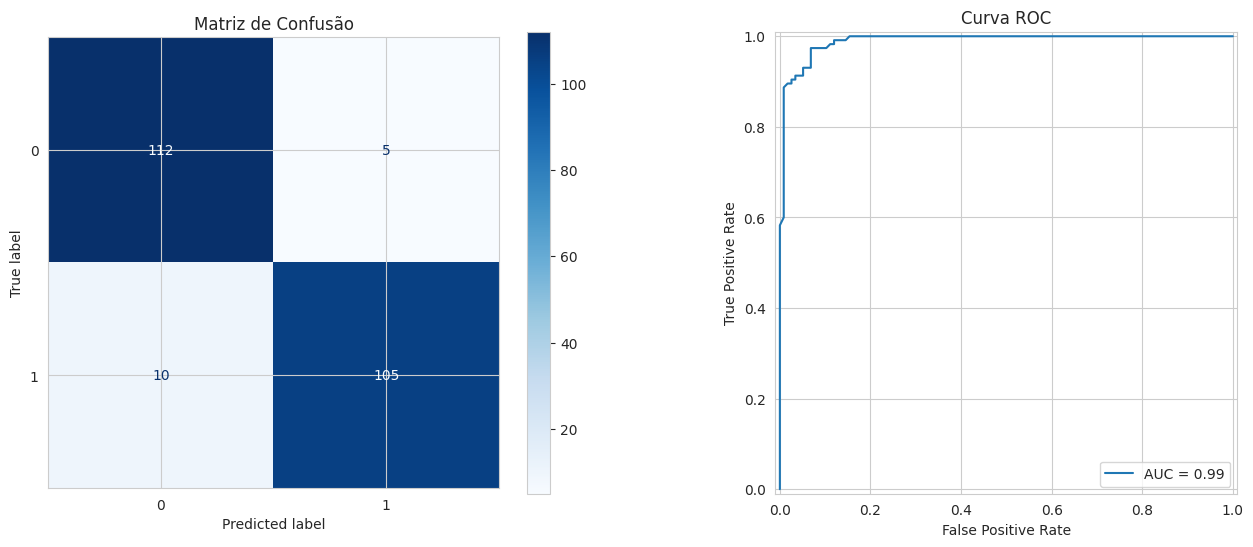

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Predições para plots
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusão')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax[1])
ax[1].set_title('Curva ROC')

plt.show()

### Importância das Features
Quais variáveis mais impactam o risco de defasagem?

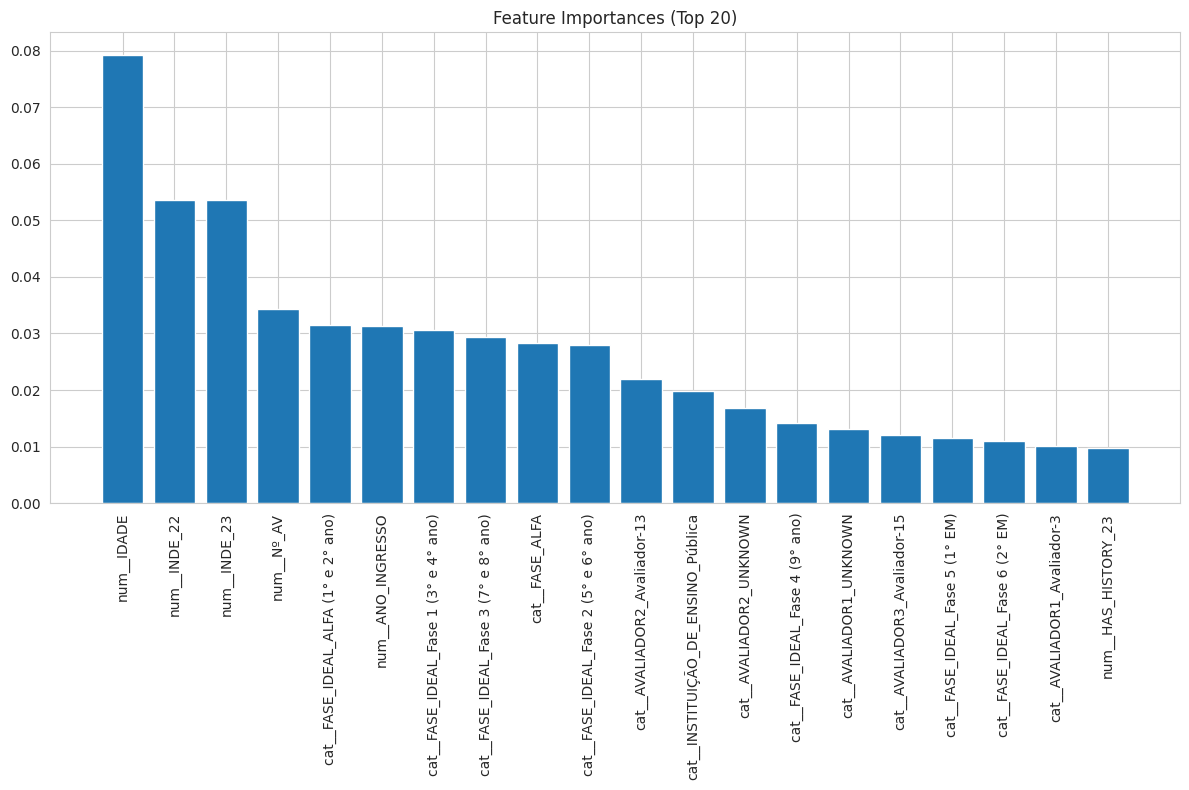

In [9]:
# Extraindo importância do pipeline
rf_model = model.named_steps['classifier']
preprocessor = model.named_steps['preprocessor']
feature_selector = model.named_steps['feature_selection']

# Recuperando nomes das features após one-hot encoding
# Nota: Isso pode ser complexo dependendo da versão do sklearn e pipeline
# Vamos tentar acessar feature_names_in_ se disponível ou usar abordagem genérica

try:
    if hasattr(model[:-1], 'get_feature_names_out'):
        feature_names = model[:-1].get_feature_names_out()
    else:
        # Fallback simplificado (apenas numeric + cat raw placeholders)
        feature_names = [f'Feat {i}' for i in range(X.shape[1])]

    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Top 20
    plt.figure(figsize=(12, 8))
    plt.title("Feature Importances (Top 20)")
    plt.bar(range(20), importances[indices][:20], align="center")
    # Se conseguimos os nomes, usamos aqui. Se não, Indices.
    try:
        plt.xticks(range(20), feature_names[indices][:20], rotation=90)
    except:
        plt.xticks(range(20), indices[:20])
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Não foi possível plotar feature importance detalhado: {e}")